In [1]:
import sys, importlib
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator')

In [2]:

import pandas as pd
import numpy as np
import geomodgen2d as gm

In [3]:
# Step 1: Unit Configuration

In [5]:
units_config = gm.Units() #Using default units config of "m"

In [6]:
# Step 2: Define Feature and Properties

In [8]:
from scipy.stats import multivariate_normal, norm
class CorrelatedUniformBivariateXLogY(gm.RandomGeneratorAbstract):
    def __init__(self, u_low_x, u_high_x, u_low_logy, u_high_logy, r_x_logy, rng=None):
        """
        Initializes a correlated uniform random generator using a Gaussian copula.

        X  ~ Uniform(u_low_x, u_high_x)
        log10(Y) ~ Uniform(log10(u_low_logy), log10(u_high_logy))
        Corr(X, log10(Y)) = r_x_logy
        
        Parameters
            u_low_x, u_high_x : float :  Range for Variable1.
            u_low_logy, u_high_logy : float : Range for Variable2.
            r : float : Correlation coefficient between Variable 1 and Variable 2.
            r_comp_axis: string : Axes scale for correlation computation.
                First element must be in {"x", "log10x"}, second in {"y", "log10y"}.
                That is Options: ['x', 'y'], ['log10x', 'log10y'], ['log10x', 'y'], ['x', 'log10y']]
        """
        self.u_low_x = u_low_x
        self.u_high_x = u_high_x
        self.u_low_logy = u_low_logy
        self.u_high_logy = u_high_logy
        
        # --- means checks ---
        if u_low_x > u_high_x:
            raise ValueError("u_low_x must be < u_high_x")
        if u_low_logy <= 0 or u_high_logy <= 0:
            raise ValueError("Log-uniform variable must be strictly positive.")
        if u_low_logy > u_high_logy:
            raise ValueError("u_low_logy must be < u_high_logy")

        # --- correlation checks ---
        if not isinstance(r_x_logy, (int, float)):
            raise TypeError("Correlation coefficient r must be a float or int.")
        if not -1 <= r_x_logy <= 1:
            raise ValueError(f"Correlation coefficient r must be between -1 and 1, got {r_x_logy}")
            
        self.r_x_logy = r_x_logy

    def generate(self, size=1):
        if isinstance(size, int):
            n = size
            out_shape = (size, 2)
        else:
            raise TypeError("size must be int")
            
        cov = [[1, self.r_x_logy], [self.r_x_logy, 1]]
        z = multivariate_normal.rvs(mean=[0, 0], cov=cov, size=size)
        u = norm.cdf(z)
        u = u.reshape(-1, 2)
        
        x = self.u_low_x + (self.u_high_x - self.u_low_x) * u[:, 0]
        logy = np.log10(self.u_low_logy) + (np.log10(self.u_high_logy) - np.log10(self.u_low_logy)) * u[:, 1]
        y = 10 ** logy
       
        samples = np.column_stack((x, y))
        return samples.reshape(out_shape)
        

In [9]:
rng = np.random.default_rng(seed=42)
layer0_flag = False

soil_materials_distribution = gm.random_generators.Constant(val = 'sand', rng=rng)

feature_config_instance =  gm.FeaturesConfig()
feature_config_instance.add_feature('def', soil_materials_distribution, 'soil')

main_properties_config_instance =  gm.MainPropertiesConfig(feature_config_instance, layer0_flag=layer0_flag)

main_properties_info = {'ec': {'desc':'electric conductivity'},
                       'dc': {'desc':"dielectric constant"},
                       }

# dc property added:
main_property_name = 'ec'
main_props_vals = main_properties_info[main_property_name]

#Define MainProperty instance
main_property_instance = gm.MainProperty(main_property_name, feature_config_instance, layer0_flag=False, description=main_props_vals['desc'])

# Define wet and dry properties
corr_coeff = 0.78
wet_mean_distribution = CorrelatedUniformBivariateXLogY(20, 30, 0.1, 1, corr_coeff, rng)
dry_mean_distribution = CorrelatedUniformBivariateXLogY(3, 5, 0.01, 0.01, corr_coeff, rng)
cov_distribution = gm.random_generators.Constant(0.05, rng)
cov_type = 'cov'
wet_prop = gm.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)
dry_prop = gm.PropertyDistribution(main_property_name,  dry_mean_distribution, cov_distribution, stdev_type=cov_type)

# Add property instance to MainProperty 
main_property_instance.add_material_property_of_feature(feature_id='def', material_name='sand', property_distribution_instance=wet_prop, property_distribution_instance_if_dry=dry_prop)

# Add MainProperty to MainPropertiesConfig instance
main_properties_config_instance.add_main_property(main_property_instance)


# DC property definition
main_property_name = 'dc'
main_props_vals = main_properties_info[main_property_name]
main_property_instance = gm.MainProperty(main_property_name, feature_config_instance, layer0_flag=layer0_flag, description=main_props_vals['desc'])
wet_mean_distribution = gm.random_generators.Constant(-999, rng)  # Filler to be replaced later
dry_mean_distribution = gm.random_generators.Constant(-999, rng)  # Filler to be replaced later
cov_distribution = gm.random_generators.Constant(0.05, rng)
cov_type = 'cov'
wet_prop = gm.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)
dry_prop = gm.PropertyDistribution(main_property_name,  dry_mean_distribution, cov_distribution, stdev_type=cov_type)
main_property_instance.add_material_property_of_feature(feature_id='def', material_name='sand', property_distribution_instance=wet_prop, property_distribution_instance_if_dry=dry_prop)
main_properties_config_instance.add_main_property(main_property_instance)



In [8]:
main_properties_config_instance.print()

Main_Properties: ['ec', 'dc']
feature_ids: ['def']
---------------------------
Property Name: ec
Description: electric conductivity
All Feature IDs: ['def']
Properties:
{'def': {'sand': {'wet': <geomodgen2d.main_property_each.PropertyDistribution object at 0x00000220CAD897B0>,
                  'dry': <geomodgen2d.main_property_each.PropertyDistribution object at 0x00000220CA791F30>}}}
---------------------------
Property Name: dc
Description: dielectric constant
All Feature IDs: ['def']
Properties:
{'def': {'sand': {'wet': <geomodgen2d.main_property_each.PropertyDistribution object at 0x00000220CADCB380>,
                  'dry': <geomodgen2d.main_property_each.PropertyDistribution object at 0x00000220CADCB5B0>}}}


In [9]:
main_properties_config_instance.main_properties['ec'].generate_sample_dict('def', 'sand')

## Here readjustment of 'means' are needed as bivariate is not in-built accompanied in geomodgen2d

{'wet': {'mean': array([[20.41357076,  0.10315246]]),
  'mean_bm': 0,
  'stdev/cov': 0.05,
  'stdev_type': 'cov'},
 'dry': {'mean': array([[4.64177443, 0.01      ]]),
  'mean_bm': 0,
  'stdev/cov': 0.05,
  'stdev_type': 'cov'}}

In [10]:
# Step 2: Model Settings

In [10]:
x_span = 5
z_span = 3

n_layers = 4
gwt_depth = 2

del_xz_spatial = 0.2    #del_y value for boundary generation and spatial 
del_xz_final = 0.1  #refining del_z for utilities generation
remesh_interp_method = 'linear'
spatial_theta_x = 100
spatial_theta_z = 0.5

interface_sett= {
    'generate_surface':False,
    'rough_interface_creator_instance':gm.rough_interface_creator2d.UniformInterfaceGen(1, rng=rng),
    'rough_interface_generator_scale': [0,1.3,1.2,1], # If n_soil_layers>len(this list) uses last value for those layers.
    'interfaces_depths_generation':[0, 0.4, 1, 2.3], 
    'interfaces_depth_reference_point_x':2.5,
    'filter_settings': {
                 'filter_window_length':21, #21 #must be odd
                 'filter_polyorder':7,
                        },
    'processing_settings': {
                'simulate_erosion': True,
            }
    }

In [11]:
# Step 2.1 Domain Creation
domain_spatial = gm.DiscretizedDomain2D(x_span, z_span, del_xz_spatial, del_xz_spatial, units_config)
domain_final   = gm.DiscretizedDomain2D(x_span, z_span, del_xz_final, del_xz_final, units_config)

<Axes: xlabel='Distance', ylabel='Depth'>

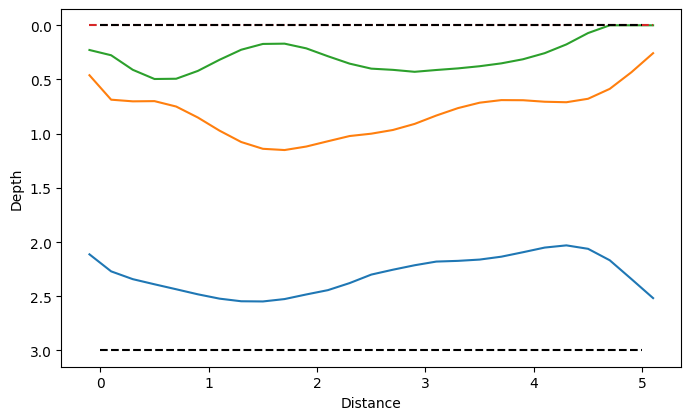

In [12]:
soil_interface = gm.DiscretizedInterfaces2DFromDict(domain_spatial, n_layers, interface_sett, remesh_interp_method=remesh_interp_method, rng=rng)
soil_interface.plot()

Ran auto test: Check
Ran auto test: Check
Ran auto test: Check


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\discretized_interfaces2d.py:507: UserWarning: Overlapping interfaces found after remesh; Applied default erosion processing at the edges to correct them. This should not affect most models.
  warnings.warn("Overlapping interfaces found after remesh; Applied default erosion processing at the edges to correct them. This should not affect most models.")


'from_interface_config'

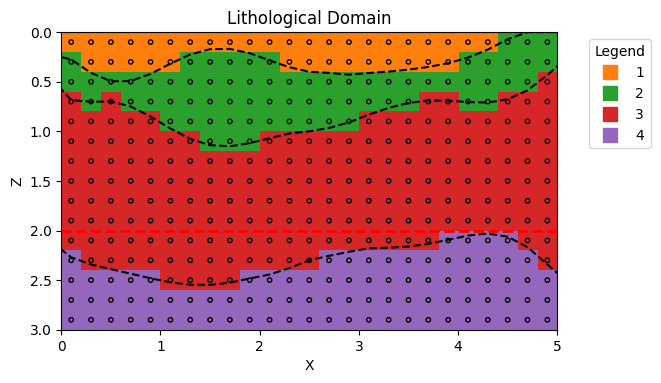

In [13]:
global_soil_interface_config = gm.GlobalSoilInterfaceConfig
global_soil_interface_config.reset()
global_soil_interface_config.set_soil_interface(soil_interface)

name = 'asdf'
lit = gm.LithologicalDomain2D(domain_spatial, gwt_depth, 'soil_lit')
lit.plot(discrete_point_size = 10, plot_interfaces=True)
lit.lm_type

In [14]:
lit_collection = gm.LithologicalDomain2DCollection(main_properties_config_instance.get_feature_ids(), interface_set_name="soil") 
lit_collection.add_lithological_domain_from_soil_interface_config(lit)
lit_collection.lock()


In [16]:
from pprint import pprint
main_properties_config_instance.unlock()
main_properties_config_instance.lock_and_generate_sample_properties(lit_collection)
sample_properties = main_properties_config_instance.sampled_properties
pprint(sample_properties)

{'dc': {'1': {'dry': {'mean': -999,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                      'stdev_type': 'cov'},
              'wet': {'mean': -999,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                      'stdev_type': 'cov'}},
        '2': {'dry': {'mean': -999,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                      'stdev_type': 'cov'},
              'wet': {'mean': -999,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                      'stdev_type': 'cov'}},
        '3': {'dry': {'mean': -999,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                      'stdev_type': 'cov'},
              'wet': {'mean': -999,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                      'stdev_type': 'cov'}},
        '4': {'dry': {'mean': -999,
                   

In [17]:
import copy
for lit_id in sample_properties['ec'].keys():
    for case in ['dry', 'wet']:
        dc_ec = sample_properties['ec'][lit_id][case]['mean']
        dc, ec = float(dc_ec[0][0]), float(dc_ec[0][1])
        sample_properties['dc'][lit_id][case]['mean'] = dc
        sample_properties['ec'][lit_id][case]['mean'] = ec
pprint(sample_properties)
main_properties_config_instance._sampled_properties = sample_properties

{'dc': {'1': {'dry': {'mean': 4.485734261204067,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                      'stdev_type': 'cov'},
              'wet': {'mean': 22.780591730775804,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                      'stdev_type': 'cov'}},
        '2': {'dry': {'mean': 4.598925773147304,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                      'stdev_type': 'cov'},
              'wet': {'mean': 24.415503487573382,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                      'stdev_type': 'cov'}},
        '3': {'dry': {'mean': 4.832928248182958,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                      'stdev_type': 'cov'},
              'wet': {'mean': 22.326593462471163,
                      'mean_bm': 0,
                      'stdev/cov': 0.05,
                   

In [18]:
main_properties_config_instance.check_consistent_with_lit_domain2d_collection(lit_collection)

In [15]:
#Spatial Simulator
spatial_sim = gm.spatial_simulator2d.CovarianceDecompositionSimulator(spatial_theta_x, spatial_theta_z, rng)
# Collection

gen_profiles = gm.GeneratedProfileCollection2D(main_properties_config_instance, lit_collection, spatial_sim)
gen_profiles.simulate_property_profile('dc')        
gen_profiles.simulate_property_profile('ec')


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'numpy.random._generator.Generator'

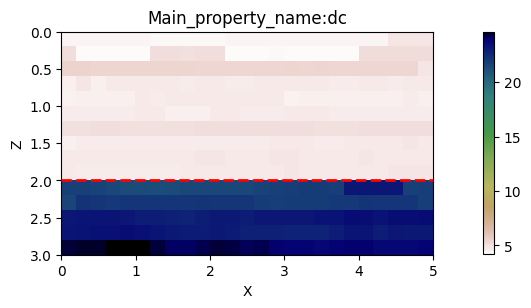

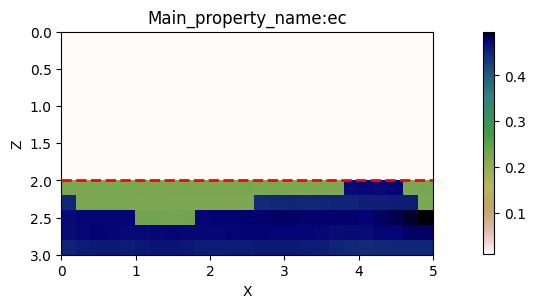

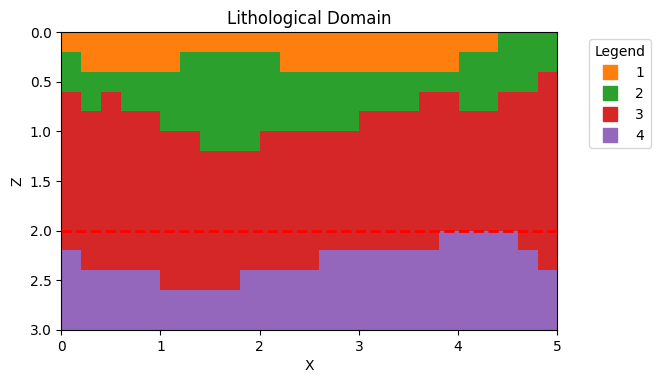

In [20]:
gen_profiles.generated_model2d_set['soil'].plot_profile('dc')
gen_profiles.generated_model2d_set['soil'].plot_profile('ec')
gen_profiles.generated_model2d_set['soil'].plot_lit_domain()#'z_vals_seismic')
# gen_profiles.get_generated_model2d('z_vals_seismic')

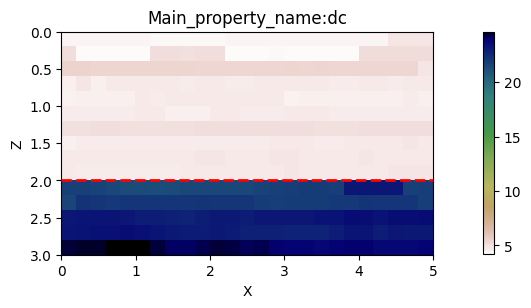

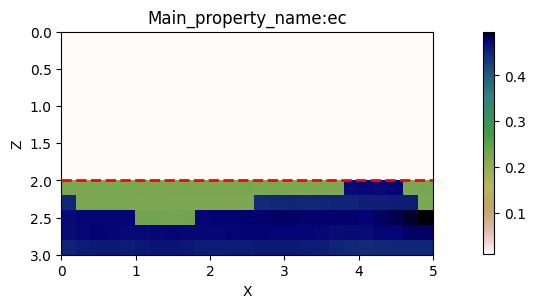

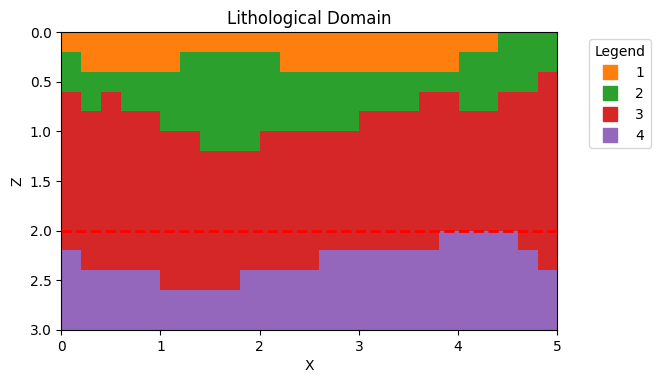

In [21]:
gen_profiles.merged_generated_model2d.plot_profile('dc')
gen_profiles.merged_generated_model2d.plot_profile('ec')
gen_profiles.merged_generated_model2d.plot_lit_domain()#'z_vals_seismic')
# gen_profiles.get_generated_model2d('z_vals_seismic')
